# Conociendo mis Datos (EDA), práctica 1 - Ciencias de Datos


# Parte I — Carga y Limpieza de Datos.



# Paso 1 Importación de librerias
 

In [2]:
# Paso 1: Importación de librerías necesarias

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paso 2 Carga del dataset

In [5]:
# Paso 2: Cargar dataset new-thyroid

df = pd.read_csv("new-thyroid.data", header=None)
df.head()

,0,1,2,3,4,5
0,1,107,10.1,2.2,0.9,2.7
1,1,113,9.9,3.1,2.0,5.9
2,1,127,12.9,2.4,1.4,0.6
3,1,109,5.3,1.6,1.4,1.5
4,1,105,7.3,1.5,1.5,-0.1


In [6]:
df.shape

(215, 6)

<span style="font-size:13px;">
Se carga correctamente el dataset utilizando separación por espacios múltiples.
Posteriormente se asignan nombres descriptivos a las columnas para facilitar la interpretación médica de las variables.
</span>

In [7]:
df.columns = [
    "class",
    "T3_resin",
    "Total_thyroxin",
    "Total_triiodothyronine",
    "Basal_TSH",
    "Max_TSH_diff"
]

df.head()

,class,T3_resin,Total_thyroxin,Total_triiodothyronine,Basal_TSH,Max_TSH_diff
0,1,107,10.1,2.2,0.9,2.7
1,1,113,9.9,3.1,2.0,5.9
2,1,127,12.9,2.4,1.4,0.6
3,1,109,5.3,1.6,1.4,1.5
4,1,105,7.3,1.5,1.5,-0.1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   class                   215 non-null    int64  
 1   T3_resin                215 non-null    int64  
 2   Total_thyroxin          215 non-null    float64
 3   Total_triiodothyronine  215 non-null    float64
 4   Basal_TSH               215 non-null    float64
 5   Max_TSH_diff            215 non-null    float64
dtypes: float64(4), int64(2)
memory usage: 10.2 KB


# Paso 3 Verificación de calidad de datos

<span style="font-size:13px;">
Se verifica la calidad del dataset identificando valores faltantes.
No se detectan datos nulos, por lo que no es necesario realizar eliminación de registros.
La variable "class" se convierte a tipo categórico ya que representa el diagnóstico clínico del paciente.
</span>

In [9]:
# Verificar valores faltantes
df.isna().sum()

class                     0
T3_resin                  0
Total_thyroxin            0
Total_triiodothyronine    0
Basal_TSH                 0
Max_TSH_diff              0
dtype: int64

In [10]:
df["class"] = df["class"].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   class                   215 non-null    category
 1   T3_resin                215 non-null    int64   
 2   Total_thyroxin          215 non-null    float64 
 3   Total_triiodothyronine  215 non-null    float64 
 4   Basal_TSH               215 non-null    float64 
 5   Max_TSH_diff            215 non-null    float64 
dtypes: category(1), float64(4), int64(1)
memory usage: 8.9 KB


## Parte II — Identificación de Atributos

## Paso 4 Revisar tipos detectados por pandas

<span style="font-size:13px;">
Se revisan los tipos de datos detectados automáticamente por pandas 
para cada variable del dataset, con el fin de compararlos posteriormente 
con su clasificación teórica.
</span>

In [11]:
# Paso 4: Tipos detectados por pandas
df.dtypes

class                     category
T3_resin                     int64
Total_thyroxin             float64
Total_triiodothyronine     float64
Basal_TSH                  float64
Max_TSH_diff               float64
dtype: object

## Paso 5 Clasificación Teórica de los Atributos

In [12]:
df.nunique()

class                       3
T3_resin                   55
Total_thyroxin            100
Total_triiodothyronine     47
Basal_TSH                  47
Max_TSH_diff               85
dtype: int64

In [13]:
tabla_atributos = pd.DataFrame({
    "Atributo": df.columns,
    "Tipo_teorico": [
        "Nominal",          # class
        "Numérico continuo",# T3_resin
        "Numérico continuo",# Total_thyroxin
        "Numérico continuo",# Total_triiodothyronine
        "Numérico continuo",# Basal_TSH
        "Numérico continuo" # Max_TSH_diff
    ],
    "Tipo_detectado_pandas": df.dtypes.values,
    "Valores_unicos": df.nunique().values
})

tabla_atributos

,Atributo,Tipo_teorico,Tipo_detectado_pandas,Valores_unicos
0,class,Nominal,category,3
1,T3_resin,Numérico continuo,int64,55
2,Total_thyroxin,Numérico continuo,float64,100
3,Total_triiodothyronine,Numérico continuo,float64,47
4,Basal_TSH,Numérico continuo,float64,47
5,Max_TSH_diff,Numérico continuo,float64,85


<span style="font-size:13px;">

1. **class** se clasifica como nominal porque representa categorías diagnósticas 
   sin orden jerárquico entre ellas (normal, hipo, hiper).

2. **T3_resin** es numérico continuo ya que corresponde a una medición clínica 
   cuantitativa obtenida en laboratorio.

3. **Total_thyroxin** es numérico continuo porque representa niveles hormonales 
   medidos en escala real.

4. **Basal_TSH** se clasifica como numérico continuo al ser una medición 
   bioquímica expresada en valores reales.

5. **Max_TSH_diff** es numérico continuo debido a que mide la variación 
   hormonal máxima en valores cuantitativos.

</span>

## Parte III Estadística Descriptiva

## Paso 6 Estadística General

<span style="font-size:13px;">
Se calculan estadísticas descriptivas generales para las variables numéricas,
incluyendo media, desviación estándar, valores mínimos, máximos y cuartiles.
</span>

In [14]:
df.describe()

,T3_resin,Total_thyroxin,Total_triiodothyronine,Basal_TSH,Max_TSH_diff
count,215.000000,215.000000,215.000000,215.000000,215.000000
mean,109.595349,9.804651,2.050233,2.880000,4.199070
std,13.145447,4.697362,1.419486,6.118031,8.070519
min,65.000000,0.500000,0.200000,0.100000,-0.700000
25%,103.000000,7.100000,1.350000,1.000000,0.550000
50%,110.000000,9.200000,1.700000,1.300000,2.000000
75%,117.500000,11.300000,2.200000,1.700000,4.100000
max,144.000000,25.300000,10.000000,56.400000,56.300000


## Paso 7 Tendencia Central

In [15]:
# Media
df[["Total_thyroxin", "Basal_TSH"]].mean()

Total_thyroxin    9.804651
Basal_TSH         2.880000
dtype: float64

In [16]:
# Mediana
df[["Total_thyroxin", "Basal_TSH"]].median()

Total_thyroxin    9.2
Basal_TSH         1.3
dtype: float64

In [17]:
# Moda
df[["Total_thyroxin", "Basal_TSH"]].mode()

,Total_thyroxin,Basal_TSH
0,8.1,1.0
1,10.4,1.3


<span style="font-size:13px;">
Se calculan las medidas de tendencia central (media, mediana y moda) 
para variables hormonales relevantes, con el fin de analizar su 
comportamiento central en la población estudiada.
</span>

## Paso 8 Medidas de Dispersión

In [18]:
variable = df["Basal_TSH"]

rango = variable.max() - variable.min()
Q1 = variable.quantile(0.25)
Q3 = variable.quantile(0.75)
IQR = Q3 - Q1
varianza = variable.var()
desviacion = variable.std()

rango, Q1, Q3, IQR, varianza, desviacion

(56.3,
 np.float64(1.0),
 np.float64(1.7),
 np.float64(0.7),
 37.430299065420556,
 6.118030652540126)

<span style="font-size:13px;">
El rango indica la amplitud total de los valores de TSH basal.
El IQR representa la dispersión del 50% central de los datos.
La varianza y la desviación estándar muestran el grado de variabilidad 
respecto a la media. Valores elevados indicarían alta dispersión hormonal.
</span>

## Paso 9 Frecuencias en Variable Categórica

In [19]:
df["class"].value_counts()

class
1    150
2     35
3     30
Name: count, dtype: int64

In [20]:
df["class"].value_counts(normalize=True)

class
1    0.697674
2    0.162791
3    0.139535
Name: proportion, dtype: float64

<span style="font-size:13px;">
Se analiza la distribución de la variable diagnóstica "class"
para identificar la proporción de pacientes en cada categoría clínica.
</span>

## Parte IV Visualización de Datos

## Paso 10 Histogramas

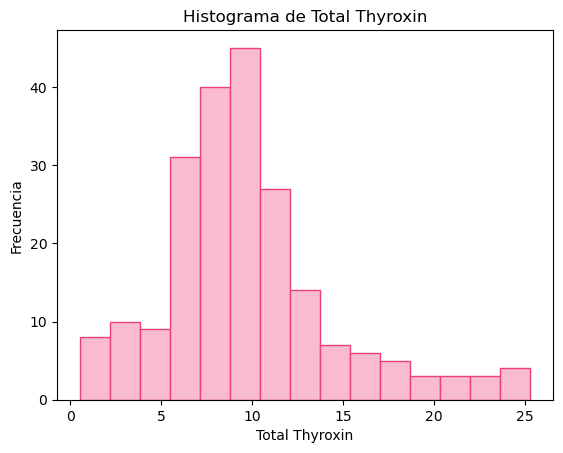

In [29]:
plt.hist(df["Total_thyroxin"], bins=15, color="#F8BBD0", edgecolor="#EC407A")
plt.title("Histograma de Total Thyroxin")
plt.xlabel("Total Thyroxin")
plt.ylabel("Frecuencia")
plt.show()

<span style="font-size:13px;">
Se genera un histograma para analizar la distribución de los niveles 
de tiroxina total en la población estudiada.
</span>

## Paso 11 Densidad (KDE)

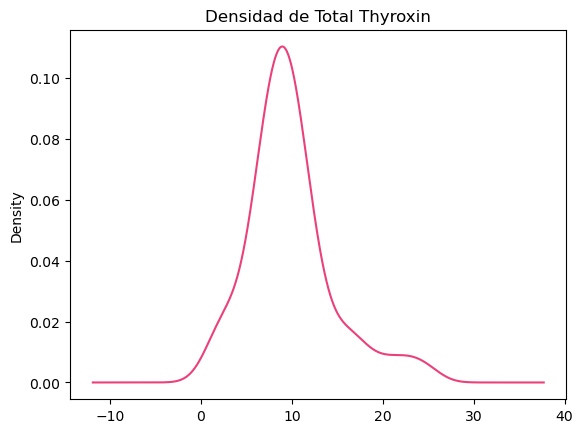

In [31]:
df["Total_thyroxin"].plot(kind="kde", color="#EC407A")
plt.title("Densidad de Total Thyroxin")
plt.show()

<span style="font-size:13px;">
La curva de densidad permite visualizar la forma de la distribución,
identificando si presenta asimetría o concentración en ciertos rangos.
</span>

## Paso 12 Boxplot

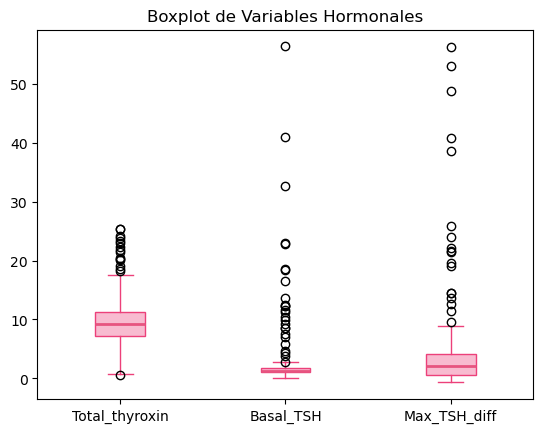

In [32]:
plt.boxplot([
    df["Total_thyroxin"],
    df["Basal_TSH"],
    df["Max_TSH_diff"]
],
patch_artist=True,
boxprops=dict(facecolor="#F8BBD0", color="#EC407A"),
medianprops=dict(color="#E75480", linewidth=2),
whiskerprops=dict(color="#EC407A"),
capprops=dict(color="#EC407A")
)

plt.xticks([1,2,3], ["Total_thyroxin", "Basal_TSH", "Max_TSH_diff"])
plt.title("Boxplot de Variables Hormonales")
plt.show()

<span style="font-size:13px;">
Los valores que aparecen fuera de los bigotes del boxplot 
se consideran posibles valores atípicos. 
En variables hormonales es común encontrar variabilidad 
debido a condiciones clínicas específicas.
</span>

## Paso 13 Scatter Plot

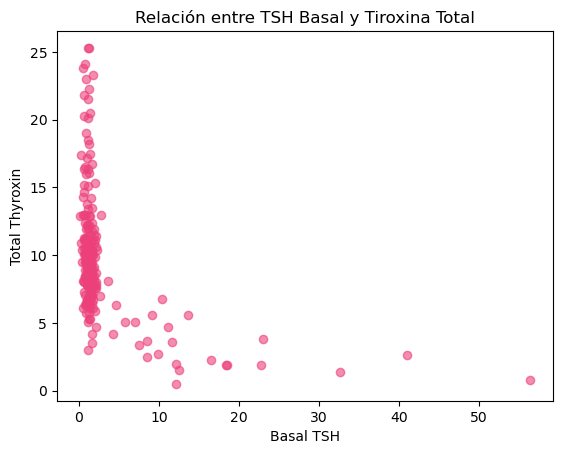

In [33]:
plt.scatter(df["Basal_TSH"], df["Total_thyroxin"], 
            color="#EC407A", alpha=0.6)

plt.xlabel("Basal TSH")
plt.ylabel("Total Thyroxin")
plt.title("Relación entre TSH Basal y Tiroxina Total")
plt.show()

<span style="font-size:13px;">
El gráfico de dispersión permite observar si existe relación 
entre los niveles de TSH basal y tiroxina total. 
Una tendencia ascendente o descendente indicaría posible correlación.
</span>

## Paso 14 Gráfica de Barras (Variable Categórica)

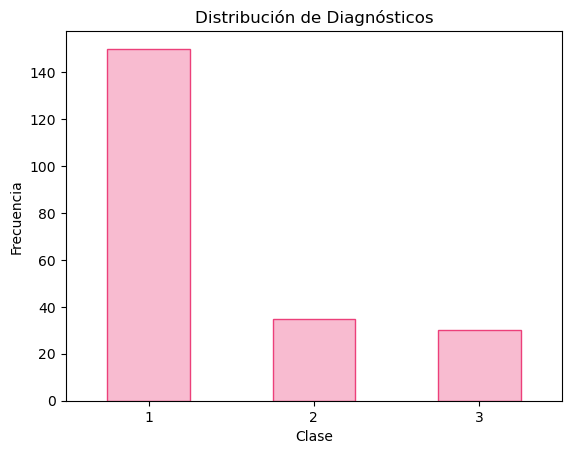

In [35]:
df["class"].value_counts().plot(kind="bar", 
                                color="#F8BBD0", 
                                edgecolor="#EC407A")

plt.title("Distribución de Diagnósticos")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.show()

<span style="font-size:13px;">
La gráfica de barras muestra la distribución de los diagnósticos 
presentes en el dataset, permitiendo identificar la clase predominante.
</span>

## Parte V Medición de Similitud y Disimilitud

## Paso 15 Selección de muestra

In [38]:
sample_df = df.sample(10, random_state=1)
sample_df = sample_df.reset_index(drop=True)

sample_df

,class,T3_resin,Total_thyroxin,Total_triiodothyronine,Basal_TSH,Max_TSH_diff
0,1,116,11.5,1.8,1.4,5.4
1,3,112,2.6,0.7,41.0,19.0
2,1,105,11.1,1.1,0.8,1.2
3,1,107,13.8,1.5,1.0,1.9
4,1,103,12.2,1.2,1.3,2.7
5,1,90,8.1,1.6,1.4,1.1
6,1,110,8.7,1.9,1.6,4.4
7,2,113,17.2,1.8,1.0,0.0
8,1,105,7.3,1.5,1.5,-0.1
9,1,116,11.1,2.0,1.2,2.3


## 5.1 Distancias Numéricas

In [40]:
num_vars = sample_df[["Total_thyroxin", 
                      "Basal_TSH", 
                      "Max_TSH_diff"]]

## Paso 16 — Minkowski

In [41]:
import numpy as np

def minkowski_distance(x, y, p):
    return np.sum(np.abs(x - y)**p) ** (1/p)

fila0 = num_vars.iloc[0]
fila1 = num_vars.iloc[1]

manhattan = minkowski_distance(fila0, fila1, 1)
euclidiana = minkowski_distance(fila0, fila1, 2)

print("Distancia Manhattan:", manhattan)
print("Distancia Euclidiana:", euclidiana)

Distancia Manhattan: 62.1
Distancia Euclidiana: 42.80572391631755


## Paso 17 Matriz 10x10 (Euclidiana)

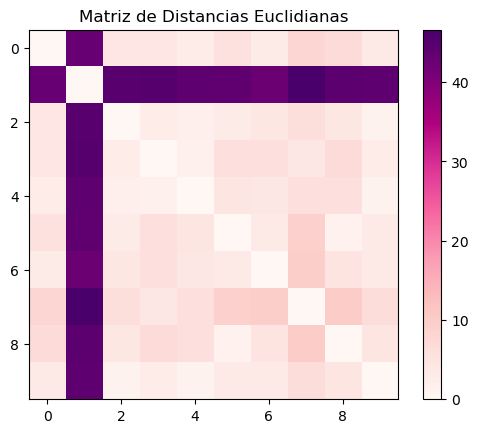

In [42]:
n = len(num_vars)
dist_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        dist_matrix[i, j] = minkowski_distance(
            num_vars.iloc[i],
            num_vars.iloc[j],
            2
        )

plt.imshow(dist_matrix, cmap="RdPu")  # rosa pastel
plt.title("Matriz de Distancias Euclidianas")
plt.colorbar()
plt.show()

## 5.2 Distancias Binarias

In [43]:
print(sample_df["class"].unique())

[1, 3, 2]
Categories (3, int64): [1, 2, 3]


In [44]:
bin_df = sample_df.copy()

bin_df["class_bin"] = bin_df["class"].apply(lambda x: 1 if x == "hyper" else 0)

bin_vars = bin_df[["class_bin"]]

## Paso 18 Hamming

In [45]:
def hamming_distance(x, y):
    return np.mean(x != y)

hamming = hamming_distance(
    bin_vars.iloc[0],
    bin_vars.iloc[1]
)

print("Distancia Hamming:", hamming)

Distancia Hamming: 0.0


## Paso 19 Jaccard

In [46]:
def jaccard_similarity(x, y):
    intersection = np.sum((x == 1) & (y == 1))
    union = np.sum((x == 1) | (y == 1))
    return intersection / union if union != 0 else 0

jaccard = jaccard_similarity(
    bin_vars.iloc[0],
    bin_vars.iloc[1]
)

print("Similitud Jaccard:", jaccard)

Similitud Jaccard: 0


## 5.3 Similitud Coseno

In [47]:
from scipy.stats import zscore

z_vars = num_vars.apply(zscore)

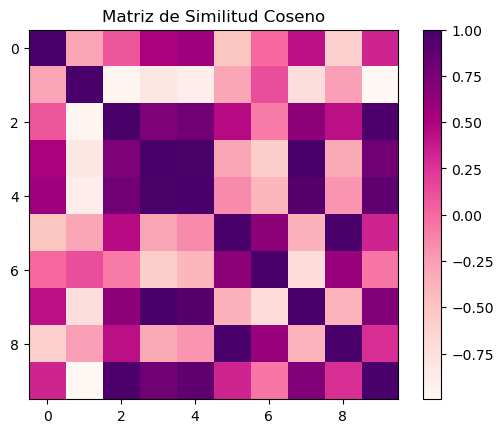

In [48]:
def cosine_similarity(x, y):
    return np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))

n = len(z_vars)
cos_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        cos_matrix[i, j] = cosine_similarity(
            z_vars.iloc[i],
            z_vars.iloc[j]
        )

plt.imshow(cos_matrix, cmap="RdPu")
plt.title("Matriz de Similitud Coseno")
plt.colorbar()
plt.show()

## 5.4 Distancia Mixta

In [50]:
range_norm = (num_vars - num_vars.min()) / (num_vars.max() - num_vars.min())

In [51]:
def mixed_distance(i, j):
    num_part = np.mean(np.abs(range_norm.iloc[i] - range_norm.iloc[j]))
    cat_part = 0 if sample_df.iloc[i]["class"] == sample_df.iloc[j]["class"] else 1
    return (num_part + cat_part) / 2

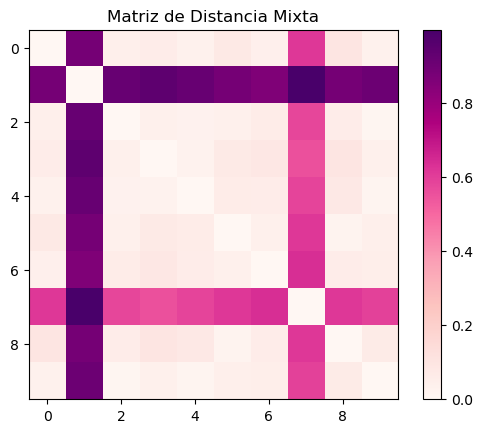

In [52]:
mixed_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        mixed_matrix[i, j] = mixed_distance(i, j)

plt.imshow(mixed_matrix, cmap="RdPu")
plt.title("Matriz de Distancia Mixta")
plt.colorbar()
plt.show()

<span style="font-size:13px;">
En esta sección se aplicaron distintas métricas de similitud y disimilitud 
sobre una muestra aleatoria de 10 pacientes del dataset de tiroides. 
Se calcularon distancias numéricas (Manhattan y Euclidiana), métricas 
para datos categóricos (Hamming y Jaccard), similitud coseno tras 
estandarización y una distancia para datos mixtos que combina variables 
numéricas normalizadas y la variable de clase. 
Este análisis permite evaluar qué tan similares o diferentes son los 
perfiles hormonales entre pacientes.
</span>